In [5]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns


In [12]:
folder_path = "12k 0 load data"
data_dictionary = {}

In [20]:
for root, dirs, files in os.walk(folder_path):
    for file in files:
        if file.endswith('.mat'):
            path = os.path.join(root, file)
            name = file.replace('.mat', '') # Clean column name
            mat_data = scipy.io.loadmat(path)
            for key in mat_data.keys():
                if 'DE_time' in key:
                    # Keep 120k points to ensure the DataFrame can be built
                    signal = mat_data[key].flatten()[:12000]
                    data_dictionary[name] = signal
                    break


In [21]:
df = pd.DataFrame(data_dictionary)
print(f"Success! Loaded {len(df.columns)} files with {len(df)} data points each.")
display(df.head())

Success! Loaded 16 files with 12000 data points each.


,Normal,07 B,14 B,21 B,28 B,07 IR,14 IR,21 IR,28 IR,07 OR1,07 OR2,07 OR3,14 OR,21 OR1,21 OR2,21 OR3
0,0.053197,-0.002761,-0.467813,-0.007959,-0.265299,-0.083004,-0.223836,1.189431,1.837967,-0.169339,0.008528,-0.102009,0.002274,0.038984,0.104365,0.132385
1,0.088662,-0.096324,0.179004,0.025340,1.621903,-0.195734,-0.209541,-0.177866,0.523273,-0.040609,0.423550,0.067248,-0.104948,-0.070659,0.017462,0.142537
2,0.099718,0.113705,0.481295,0.000162,-0.035807,0.233419,0.345337,-0.774816,-0.329589,0.365073,0.012995,0.005035,0.082010,-0.330393,0.116547,0.004873
3,0.058621,0.257297,-0.158212,0.092913,-2.014969,0.103958,0.158862,0.501518,-0.485025,0.186394,-0.265175,0.001137,0.094027,-0.220749,0.371164,-0.010558
4,-0.004590,-0.058314,-0.326819,-0.007797,0.262857,-0.181115,-0.206617,0.993697,-0.902097,-0.492585,0.237155,0.052791,-0.160081,0.551792,0.356951,0.179491


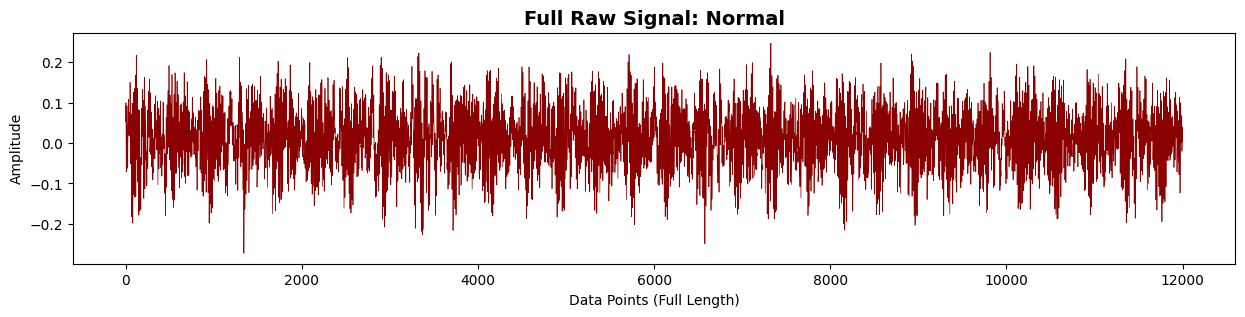

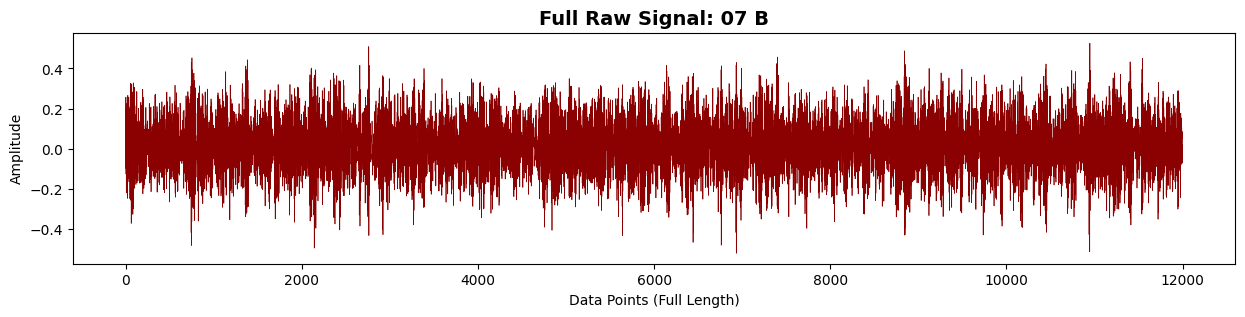

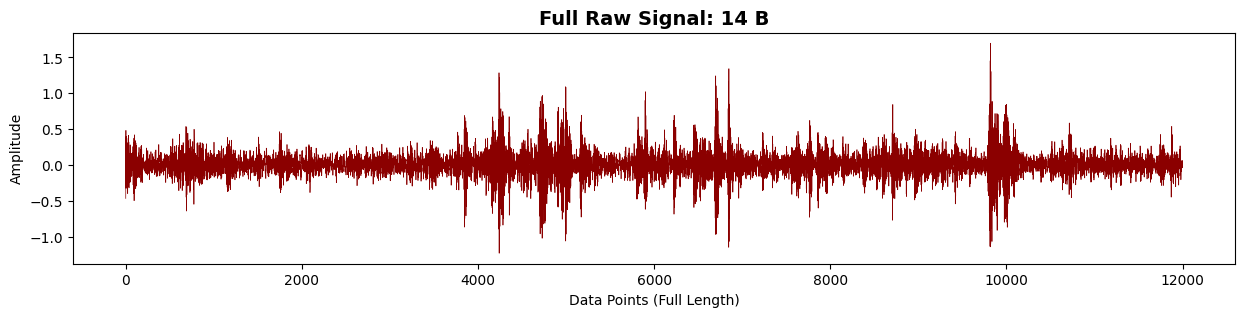

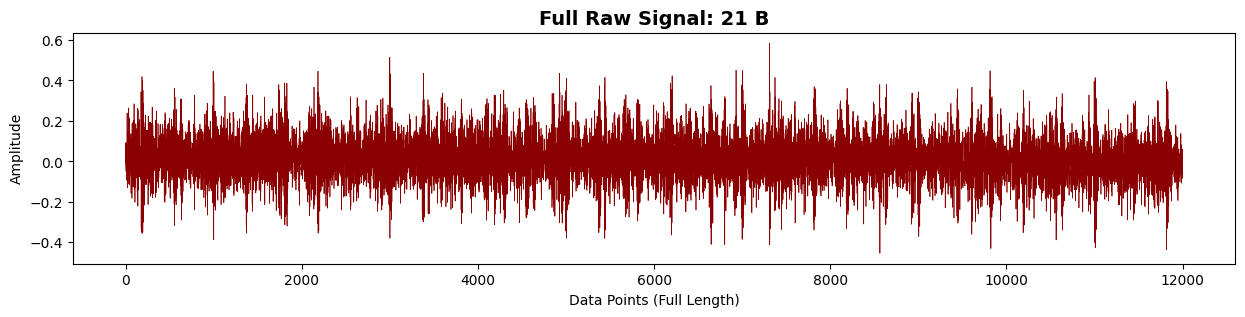

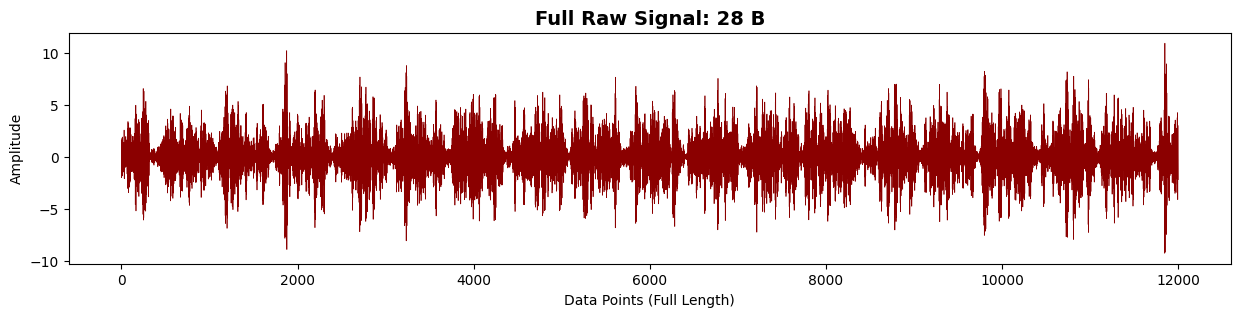

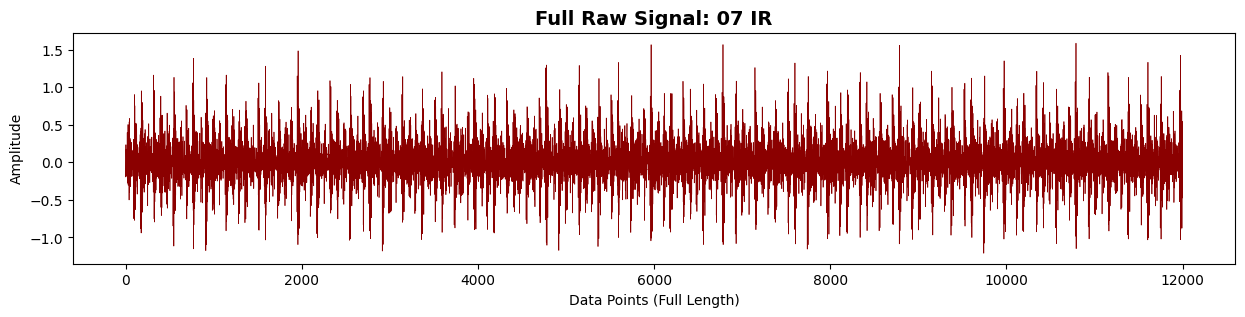

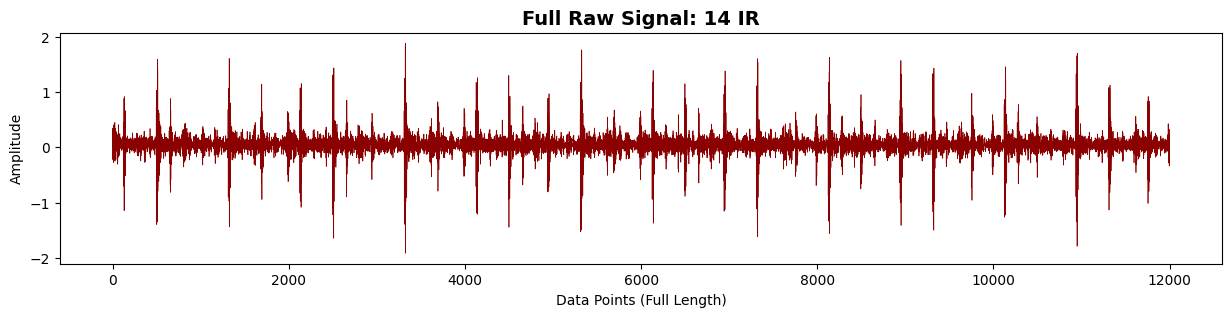

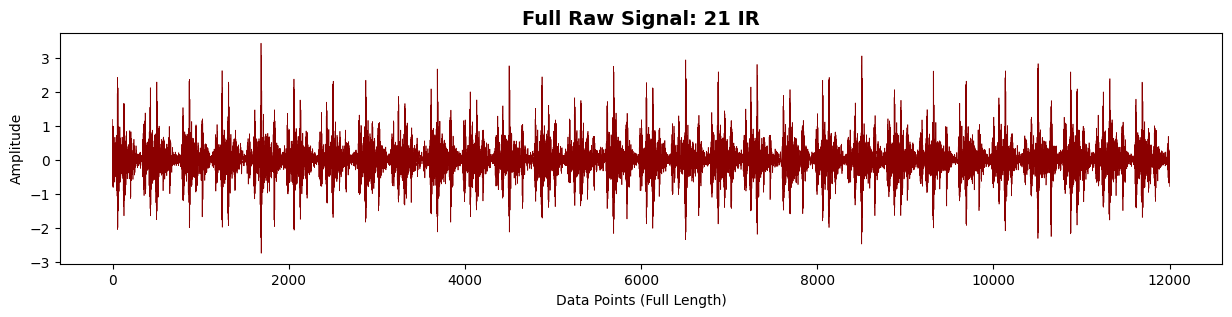

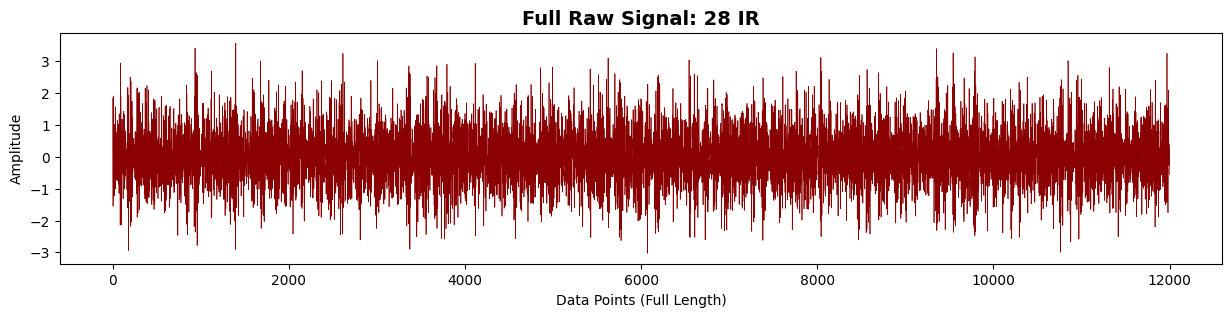

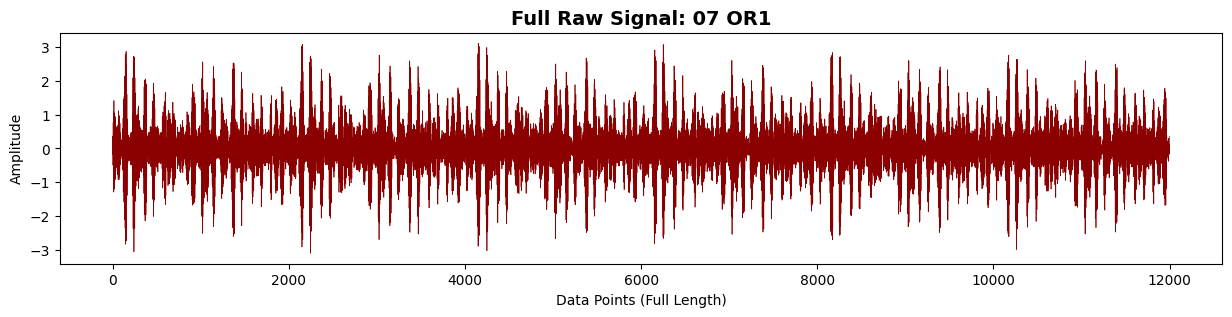

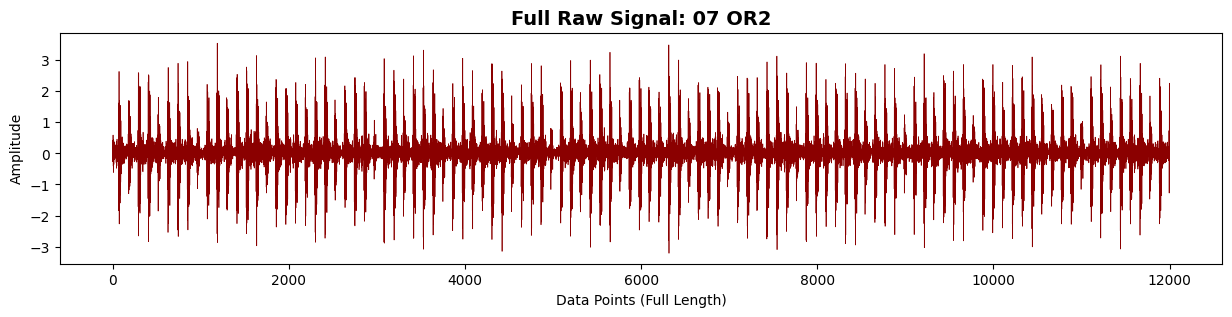

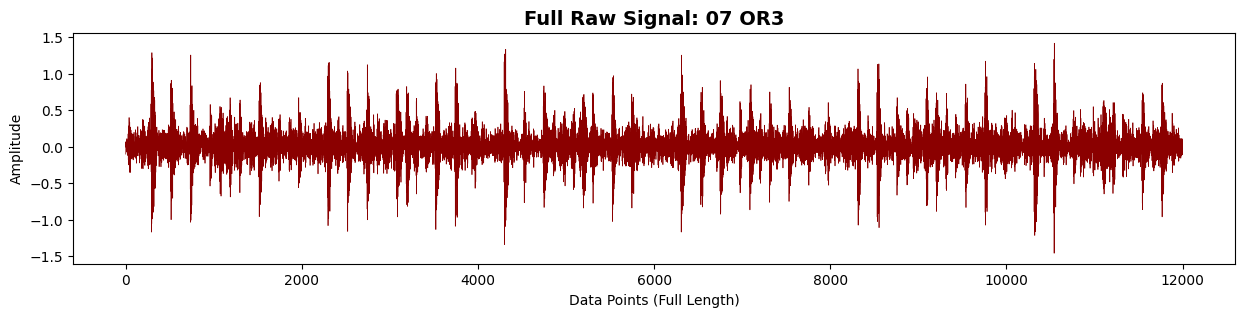

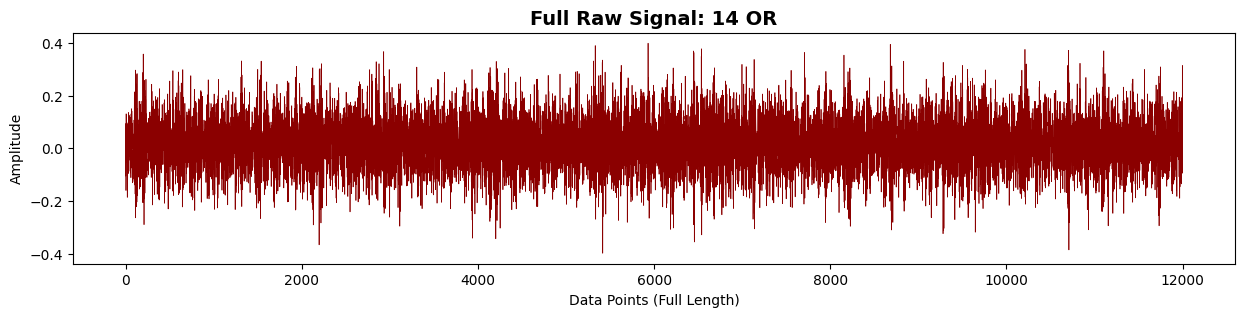

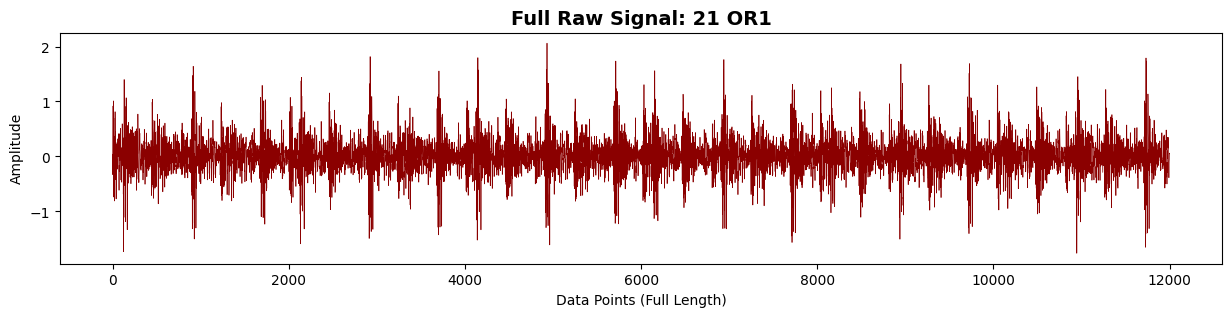

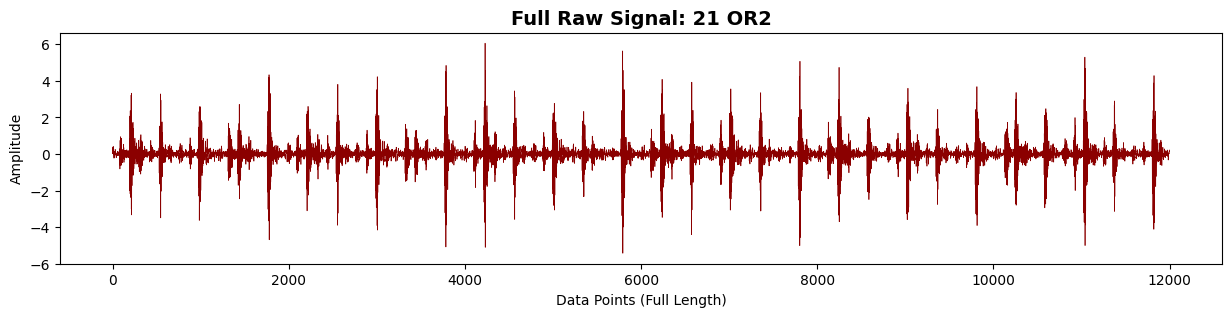

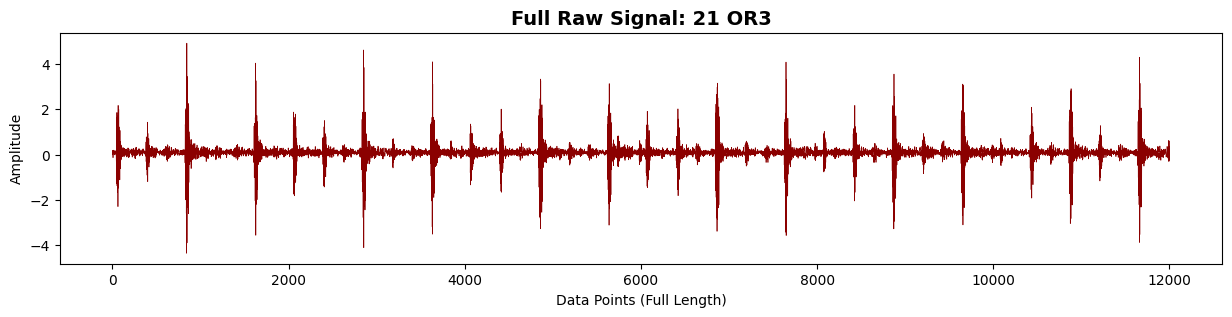

In [22]:
# Loop through every column (file) in your table
for col in df.columns:
    
    # 1. Create a wide canvas
    plt.figure(figsize=(15, 3))
    
    # 2. Plot the ENTIRE signal. 
    plt.plot(df[col], color='darkred', linewidth=0.5)
    
    # 3. Add labels
    plt.title(f"Full Raw Signal: {col}", fontweight='bold', fontsize=14)
    plt.xlabel("Data Points (Full Length)")
    plt.ylabel("Amplitude")
    
    # NO X-AXIS LIMITS AND NO Y-AXIS LIMITS HERE!
    
    plt.show()

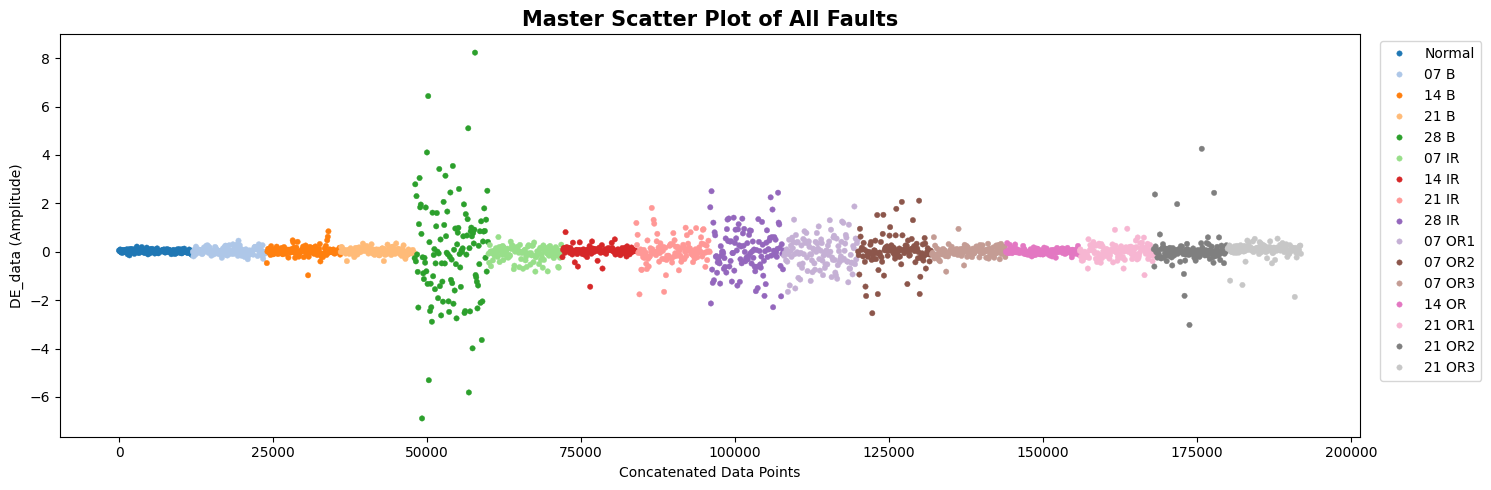

In [23]:
# 1. "Melt" the table so Seaborn can read it (stacking the columns)
df_long = df.melt(var_name='fault', value_name='DE_data')

# 2. Create a wide canvas
plt.figure(figsize=(15, 5))

# 3. Draw the scatter plot exactly like your screenshot
# We plot every 100th point [::100] to render it cleanly and safely
sns.scatterplot(
    data=df_long.iloc[::100, :], 
    x=np.arange(0, len(df_long), 100), 
    y='DE_data', 
    hue='fault',
    palette='tab20',
    s=15,
    edgecolor=None
)

# 4. Clean up the labels and legend
plt.title("Master Scatter Plot of All Faults", fontweight='bold', fontsize=15)
plt.xlabel("Concatenated Data Points")
plt.ylabel("DE_data (Amplitude)")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left') # Moves legend outside the box
plt.tight_layout()
plt.show()